### Chuẩn bị dữ liệu

In [1]:
from google.colab import userdata
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('datathon-2026-round-1')

print("Path to competition files:", path)

100%|██████████| 27.7M/27.7M [00:00<00:00, 109MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/datathon-2026-round-1


In [4]:
folder = path

dfs = {}
files = os.listdir(folder)

for filename in files:
  if filename.endswith('.csv'):
    key = filename.replace('.csv', '')
    print(key)
    dfs[key] = pd.read_csv(os.path.join(folder, filename), low_memory=False)

web_traffic
products
orders
shipments
sample_submission
sales
payments
reviews
promotions
order_items
customers
geography
inventory
returns


In [5]:
# Bảng Master
df_products = dfs['products']
df_customers = dfs['customers']
df_promotions = dfs['promotions']
df_geography = dfs['geography']

# Bảng Transaction
df_order = dfs['orders']
df_order_items = dfs['order_items']
df_payments = dfs['payments']
df_shipments = dfs['shipments']
df_returns = dfs['returns']
df_reviews = dfs['reviews']

# Bảng Analytical
df_sales = dfs['sales']

# Bảng Operational
df_inventory = dfs['inventory']
df_web_traffic = dfs['web_traffic']

In [6]:
df_customers.signup_date = pd.to_datetime(df_customers.signup_date).dt.date
df_promotions.start_date = pd.to_datetime(df_promotions.start_date).dt.date
df_promotions.end_date = pd.to_datetime(df_promotions.end_date).dt.date
df_order.order_date = pd.to_datetime(df_order.order_date).dt.date
df_shipments.ship_date = pd.to_datetime(df_shipments.ship_date).dt.date
df_shipments.delivery_date = pd.to_datetime(df_shipments.delivery_date).dt.date
df_returns.return_date = pd.to_datetime(df_returns.return_date).dt.date
df_reviews.review_date = pd.to_datetime(df_reviews.review_date).dt.date
df_sales.Date = pd.to_datetime(df_sales.Date).dt.date
df_inventory.snapshot_date = pd.to_datetime(df_inventory.snapshot_date).dt.date
df_web_traffic.date = pd.to_datetime(df_web_traffic.date).dt.date

### Modeling

#### DIM

In [7]:
dim_product = df_products.copy()

In [8]:
dim_customer = df_customers.drop(columns=['zip', 'city'])

In [9]:
dim_geography = df_geography.copy()

In [10]:
dim_promotion = df_promotions.copy()

In [11]:
min_date = '2012-07-04'
max_date = '2024-07-01'

dim_date = pd.DataFrame({'Date': pd.date_range(start=min_date, end=max_date)})
dim_date['Year'] = dim_date['Date'].dt.year
dim_date['Quarter'] = dim_date['Date'].dt.quarter
dim_date['Month'] = dim_date['Date'].dt.month
dim_date['Day'] = dim_date['Date'].dt.day
dim_date['DayOfWeek'] = dim_date['Date'].dt.dayofweek # Thứ 2 = 0, Chủ nhật = 6
dim_date['IsWeekend'] = np.where(dim_date['DayOfWeek'].isin([5, 6]), 1, 0)

#### FACT

In [12]:
# Hợp nhất order_items với orders
fact_sales = pd.merge(df_order_items, df_order, on='order_id', how='left')

# Lấy giá vốn (cogs) từ products để tính toán Total_COGS
fact_sales = pd.merge(fact_sales, df_products[['product_id', 'cogs']], on='product_id', how='left')

# Hợp nhất với shipments để lấy shipping_fee và ngày giao hàng (1:0 hoặc 1)
fact_sales = pd.merge(fact_sales, df_shipments[['order_id', 'ship_date', 'delivery_date', 'shipping_fee']], on='order_id', how='left')

# Xử lý missing values cho shipping_fee (nếu không có shipment, phí = 0)
fact_sales['shipping_fee'] = fact_sales['shipping_fee'].fillna(0)

# Xử lý missing values cho discount_amount
fact_sales['discount_amount'] = fact_sales['discount_amount'].fillna(0)

# TÍNH TOÁN METRICS (Các chỉ số quan trọng)
# Doanh thu thuần từng dòng: (Số lượng * Đơn giá) - Giảm giá
fact_sales['Revenue'] = (fact_sales['quantity'] * fact_sales['unit_price']) - fact_sales['discount_amount']

# Tổng giá vốn: Số lượng * cogs
fact_sales['Total_COGS'] = fact_sales['quantity'] * fact_sales['cogs']

# Lợi nhuận gộp (Gross Profit)
fact_sales['Gross_Profit'] = fact_sales['Revenue'] - fact_sales['Total_COGS']

fact_sales_columns = [
    'order_id', 'product_id', 'customer_id', 'zip', 'promo_id', 'promo_id_2',
    'order_date', 'ship_date', 'delivery_date', 'order_status', 'order_source', 'device_type',
    'quantity', 'unit_price', 'discount_amount', 'shipping_fee',
    'Total_COGS', 'Revenue', 'Gross_Profit'
]
fact_sales = fact_sales[fact_sales_columns]

In [13]:
# fact phụ
fact_returns = df_returns.copy()
fact_reviews = df_reviews.copy()
fact_inventory = df_inventory.copy()
fact_web_traffic = df_web_traffic.copy()
fact_daily_sale = df_sales.copy()

## Xuất file

In [ ]:
print('Đang chế biến... Dự kiến 6 phút...')

with pd.ExcelWriter('modeling.xlsx') as writer:
  fact_sales.to_excel(writer, sheet_name='Fact SALE', index=False)
  fact_returns.to_excel(writer, sheet_name='Fact Return', index=False)
  fact_reviews.to_excel(writer, sheet_name='Fact Review', index=False)
  fact_inventory.to_excel(writer, sheet_name='Fact Inventory', index=False)
  fact_web_traffic.to_excel(writer, sheet_name='Fact Web Traffic', index=False)
  fact_daily_sale.to_excel(writer, sheet_name='Fact Daily Sale', index=False)
  dim_product.to_excel(writer, sheet_name='Dim Product', index=False)
  dim_customer.to_excel(writer, sheet_name='Dim Customer', index=False)
  dim_geography.to_excel(writer, sheet_name='Dim Geography', index=False)
  dim_promotion.to_excel(writer, sheet_name='Dim Promotion', index=False)
  dim_date.to_excel(writer, sheet_name='Dim DATE', index=False)

print('Sườn xào chua ngọt đã chế biến xong!')

Đang chế biến... Dự kiến 6 phút...
Sườn xào chua ngọt đã chế biến xong!


## 💥Insight 1: Lỗ hổng trong cách tính doanh thu
**Doanh thu (Revenue) trong file `sale.csv` ghi nhận cả doanh thu của đơn hủy + không khấu trừ khuyến mãi**

In [14]:
print("Tổng số ngày phát sinh giao dịch:", df_sales.Date.nunique())

Tổng số ngày phát sinh giao dịch: 3833


In [15]:
# KIỂM TRA XEM NGUYÊN DO DOANH THU TỰ TÍNH KHÔNG KHỚP VỚI DOANH THU `sale.csv`

# Kịch bản 1: Doanh thu BAO GỒM cả đơn bị Hủy
scen_1 = fact_sales.groupby('order_date').agg(
    Gross_All_Revenue=('Revenue', 'sum'),
    Gross_All_COGS=('Total_COGS', 'sum')
).reset_index()

# Kịch bản 2: Doanh thu KHÔNG BAO GỒM đơn bị Hủy
scen_2 = fact_sales[fact_sales['order_status'] != 'cancelled'].groupby('order_date').agg(
    Gross_NoCancel_Revenue=('Revenue', 'sum'),
    Gross_NoCancel_COGS=('Total_COGS', 'sum')
).reset_index()

# Nối với df_sales gốc để đối chiếu
debug_df = pd.merge(df_sales, scen_1, left_on='Date', right_on='order_date', how='inner')
debug_df = pd.merge(debug_df, scen_2, on='order_date', how='inner')

# Tính độ lệch với từng kịch bản
debug_df['scen_1_cancel'] = debug_df['Gross_All_Revenue'] - debug_df['Revenue']
debug_df['scen_2_no_cancel'] = debug_df['Gross_NoCancel_Revenue'] - debug_df['Revenue']

print("BẢNG ĐỐI SOÁT TÌM NGUYÊN DO DOANH THU TỰ TÍNH KHÔNG KHỚP VỚI DOANH THU `sale.csv`:")
display(debug_df[['Date', 'Revenue', 'scen_1_cancel', 'scen_2_no_cancel']].head(5))
display(debug_df[['Date', 'Revenue', 'scen_1_cancel', 'scen_2_no_cancel']].tail(5))

BẢNG ĐỐI SOÁT TÌM NGUYÊN DO DOANH THU TỰ TÍNH KHÔNG KHỚP VỚI DOANH THU `sale.csv`:


,Date,Revenue,scen_1_cancel,scen_2_no_cancel
0,2012-07-04,5123547.94,0.0,-154785.82
1,2012-07-05,2751773.45,0.0,-231051.66
2,2012-07-06,3054029.42,0.0,-407538.87
3,2012-07-07,2667930.94,0.0,-330033.98
4,2012-07-08,2360851.90,0.0,-161578.53


,Date,Revenue,scen_1_cancel,scen_2_no_cancel
3828,2022-12-27,2100553.66,-420110.73,-590352.86
3829,2022-12-28,3448729.20,-689745.86,-923052.68
3830,2022-12-29,3083944.33,-616788.80,-1055153.30
3831,2022-12-30,2884668.76,-561274.89,-802755.55
3832,2022-12-31,2383037.48,-367055.45,-388310.26


==> Vẫn còn những ngày chưa rõ nguyên do lệch doanh thu

Nghi ngờ: Doanh thu lệch có thể chưa trừ đi khuyến mãi

In [16]:
# Lọc bỏ các sai số thập phân (nhỏ hơn 1 thì coi như bằng 0)
debug_df = debug_df[abs(debug_df['scen_1_cancel']) > 1.0].copy()
print(f"Số ngày vẫn bị lệch doanh thu: {len(debug_df)} ngày")

Số ngày vẫn bị lệch doanh thu: 1707 ngày


In [17]:
# 1. Tính TỔNG TIỀN KHUYẾN MÃI đã phát hành cho mỗi ngày từ fact_sales (bao gồm đơn hủy)
daily_discount = fact_sales.groupby('order_date').agg(
    Total_Discount_Amount=('discount_amount', 'sum'),
    Total_Orders=('order_id', 'nunique'),
    Promo_Orders=('promo_id', lambda x: x.notnull().sum()) # Đếm số dòng dùng mã
).reset_index()

# 2. Ghép với bảng những ngày bị lệch
proof_df = pd.merge(debug_df, daily_discount, left_on='Date', right_on='order_date', how='left')

# Lấy giá trị tuyệt đối của độ lệch để so sánh với tổng tiền khuyến mãi
proof_df['Abs_Diff_Scen_1'] = proof_df['scen_1_cancel'].abs()
proof_df['Difference_Between_Diff_and_Discount'] = (proof_df['Abs_Diff_Scen_1'] - proof_df['Total_Discount_Amount']).round(2)

# 3. CHỨNG MINH: Có bao nhiêu ngày LỆCH DOANH THU = ĐÚNG BẰNG TIỀN KHUYẾN MÃI?
perfect_match = len(proof_df[proof_df['Difference_Between_Diff_and_Discount'] == 0])
total_anomalies = len(proof_df)

print(f"Số ngày lệch doanh thu sau khi đã gộp đơn hủy: {total_anomalies} ngày")
print(f"Số ngày mà tiền lệch CHÍNH XÁC bằng tiền khuyến mãi: {perfect_match} ngày")

if perfect_match == total_anomalies:
    print("\n=> KẾT LUẬN: 100% CÁC NGÀY SAI LỆCH LÀ DO HỆ THỐNG QUÊN TRỪ TIỀN KHUYẾN MÃI!")
else:
    print(f"\n=> Tỷ lệ khớp: {(perfect_match/total_anomalies)*100:.2f}%")

print("\nChi tiết 5 ngày lệch ngẫu nhiên:")
display(proof_df[['Date', 'Abs_Diff_Scen_1', 'Total_Discount_Amount', 'Difference_Between_Diff_and_Discount']].sample(5))

Số ngày lệch doanh thu sau khi đã gộp đơn hủy: 1707 ngày
Số ngày mà tiền lệch CHÍNH XÁC bằng tiền khuyến mãi: 1707 ngày

=> KẾT LUẬN: 100% CÁC NGÀY SAI LỆCH LÀ DO HỆ THỐNG QUÊN TRỪ TIỀN KHUYẾN MÃI!

Chi tiết 5 ngày lệch ngẫu nhiên:


,Date,Abs_Diff_Scen_1,Total_Discount_Amount,Difference_Between_Diff_and_Discount
1305,2020-09-15,291453.64,291453.64,-0.0
658,2016-12-09,510656.78,510656.78,0.0
1166,2019-09-16,337767.71,337767.71,-0.0
805,2017-08-29,59650.00,59650.00,0.0
359,2015-02-17,109270.43,109270.43,-0.0


In [18]:
proof_table = proof_df[['Date', 'Abs_Diff_Scen_1', 'Total_Discount_Amount', 'Difference_Between_Diff_and_Discount']].copy()
proof_table.rename(columns={
    'Date': 'Ngày giao dịch',
    'Abs_Diff_Scen_1': 'Tổng số tiền lệch',
    'Total_Discount_Amount': 'Tổng số tiền giảm giá',
    'Difference_Between_Diff_and_Discount': 'Chênh lệch'
}, inplace=True)

print("BẢNG SO SÁNH ĐỘ LỆCH DOANH THU VỚI TỔNG SỐ TIỀN KHUYẾN MÃI")
proof_table.sample(5)

BẢNG SO SÁNH ĐỘ LỆCH DOANH THU VỚI TỔNG SỐ TIỀN KHUYẾN MÃI


,Ngày giao dịch,Tổng số tiền lệch,Tổng số tiền giảm giá,Chênh lệch
1191,2019-11-27,334772.56,334772.56,0.0
1467,2021-08-07,11150.00,11150.00,0.0
1083,2019-04-13,389853.29,389853.29,0.0
622,2016-09-17,443168.05,443168.05,-0.0
1567,2021-12-31,581582.21,581582.21,0.0


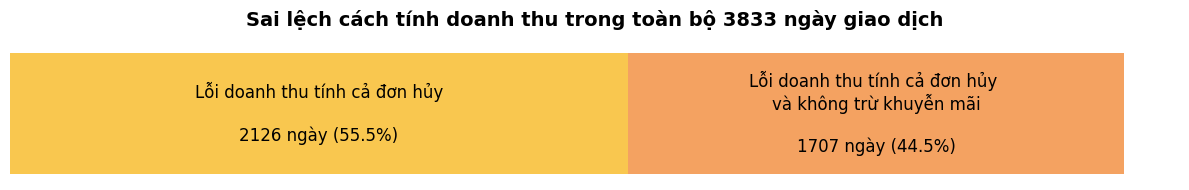

In [19]:
# Trực quan
total_days = fact_sales.order_date.nunique()
error_2_days = total_anomalies
error_1_days = total_days - error_2_days

pct_1 = (error_1_days / total_days) * 100
pct_2 = (error_2_days / total_days) * 100

fig, ax = plt.subplots(figsize=(12, 2))

# Đặt tên từng thanh bar
ax.barh('Toàn bộ thời gian\n(3.833 ngày)', error_1_days, color='#F9C74F')
ax.barh('Toàn bộ thời gian\n(3.833 ngày)', error_2_days, left=error_1_days, color='#F4A261')

text_error_1 = f"Lỗi doanh thu tính cả đơn hủy\n\n{error_1_days} ngày ({pct_1:.1f}%)"
text_error_2 = f"Lỗi doanh thu tính cả đơn hủy \nvà không trừ khuyễn mãi\n\n{error_2_days} ngày ({pct_2:.1f}%)"

# Gắn chữ trực tiếp vào giữa mỗi phần của thanh biểu đồ
ax.text(error_1_days / 2, 0, text_error_1, ha='center', va='center', color='black', fontsize=12)
ax.text(error_1_days + (error_2_days / 2), 0, text_error_2, ha='center', va='center', color='black', fontsize=12)

# Xóa viền và trục tọa độ để biểu đồ gọn gàng, clean nhất
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([]) # Ẩn trục X
ax.set_yticks([]) # Ẩn trục Y

# Tiêu đề biểu đồ
plt.title('Sai lệch cách tính doanh thu trong toàn bộ 3833 ngày giao dịch', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Lưu ảnh chất lượng cao để chèn vào báo cáo LaTeX
# plt.savefig('Data_Anomaly_Bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 💥Insight 3: Rủi ro hoàn hàng do sai kích cỡ và lỗ hổng kiểm định chất lượng

In [20]:
fact_returns.head()

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


    Lý do hoàn hàng  Số lần xuất hiện
4     late_delivery              3986
3      changed_mind              6931
2  not_as_described              7035
1         defective              8020
0        wrong_size             13967
--------------------------------------------------


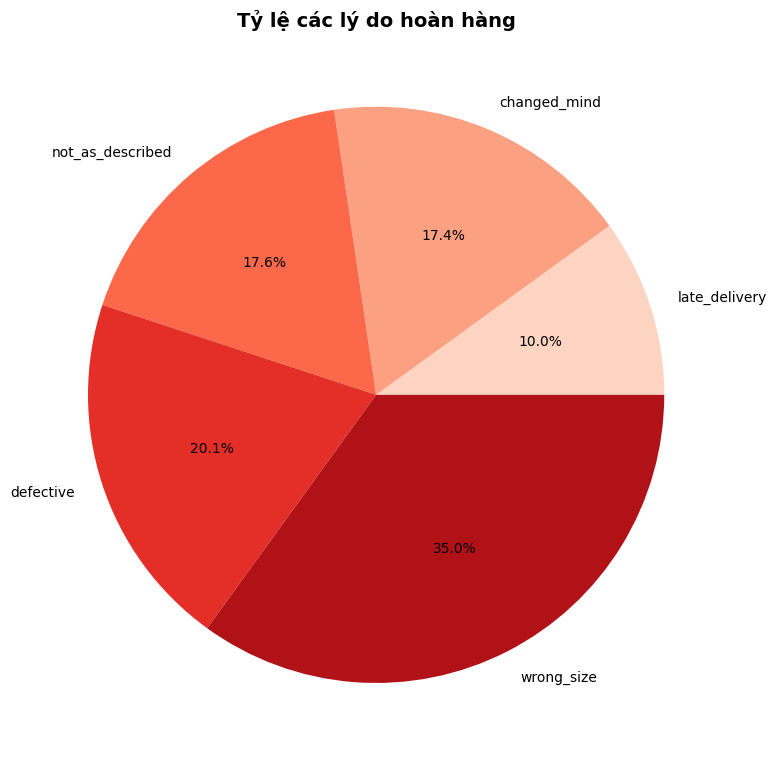

In [21]:
# 1. BẢNG TẦN SUẤT LÝ DO HOÀN HÀNG
reason_freq = fact_returns['return_reason'].value_counts().reset_index()
reason_freq.columns = ['Lý do hoàn hàng', 'Số lần xuất hiện']
reason_freq = reason_freq.sort_values(by='Số lần xuất hiện', ascending=True)

print(reason_freq)
print("-" * 50)

plt.figure(figsize=(8, 8))
plt.pie(reason_freq['Số lần xuất hiện'],
        labels=reason_freq['Lý do hoàn hàng'],
        autopct='%1.1f%%',
        startangle=0,
        colors=sns.color_palette("Reds", n_colors=len(reason_freq)))
plt.title('Tỷ lệ các lý do hoàn hàng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2343/385165428.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(left_cumulative[i] + w/2, i, f'{sub_percentage:.1f}%',


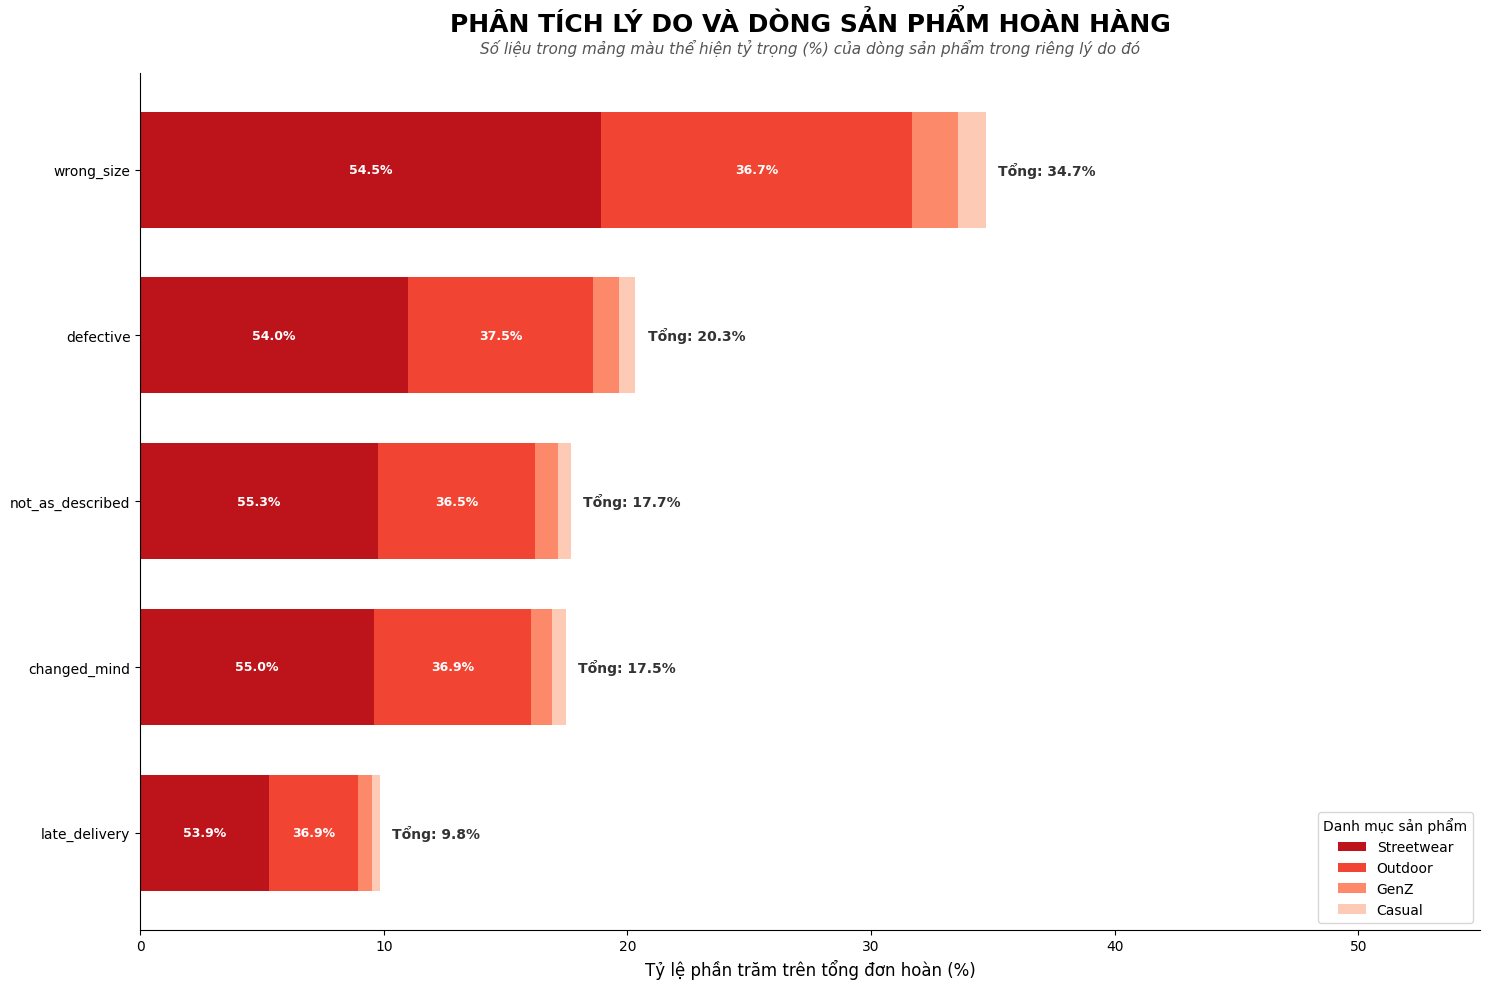

<Figure size 640x480 with 0 Axes>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Merge và chuẩn bị dữ liệu
df_returns_category = fact_returns.merge(dim_product[['product_id', 'category']], on='product_id', how='left')
df_returns_category['category'] = df_returns_category['category'].fillna('Unknown')

# Tính tổng thiệt hại để đưa vào ghi chú
total_wrong_size_refund_amount = df_returns_category[
    (df_returns_category['return_reason'] == 'wrong_size') &
    (df_returns_category['category'].isin(['Streetwear', 'Outdoor']))
]['refund_amount'].sum()

# 2. Xây dựng bảng Pivot cho tỷ lệ % trên tổng
returns_agg = df_returns_category.groupby(['return_reason', 'category'])['return_quantity'].sum().reset_index()
overall_total_qty = returns_agg['return_quantity'].sum()
returns_agg['percentage_of_overall'] = (returns_agg['return_quantity'] / overall_total_qty) * 100

plot_data_stacked = returns_agg.pivot_table(index='return_reason', columns='category', values='percentage_of_overall', fill_value=0)

# 3. Sắp xếp thứ tự ưu tiên
reason_order = ['wrong_size', 'defective', 'not_as_described', 'changed_mind', 'late_delivery']
plot_data_stacked = plot_data_stacked.reindex(reason_order, fill_value=0)
sorted_category_order = ['Streetwear', 'Outdoor', 'GenZ', 'Casual'] # Cố định thứ tự để màu sắc nhất quán
plot_data_stacked = plot_data_stacked[sorted_category_order]

# 4. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(15, 10))
colors = sns.color_palette('Reds_r', len(sorted_category_order))
category_color_map = dict(zip(sorted_category_order, colors))

left_cumulative = np.zeros(len(plot_data_stacked))

for category in plot_data_stacked.columns:
    widths = plot_data_stacked[category]
    rects = ax.barh(plot_data_stacked.index, widths, left=left_cumulative,
                    label=category, color=category_color_map[category], height=0.7)

    for i, (w, total) in enumerate(zip(widths, plot_data_stacked.sum(axis=1))):
        if w > 2:
            # Tính % của category trong riêng lý do đó
            sub_percentage = (w / total) * 100
            ax.text(left_cumulative[i] + w/2, i, f'{sub_percentage:.1f}%',
                    va='center', ha='center', color='white', fontsize=9, fontweight='bold')

    left_cumulative += widths

# 5. Thêm tổng % ở cuối thanh
for i, total in enumerate(plot_data_stacked.sum(axis=1)):
    ax.text(total + 0.5, i, f'Tổng: {total:.1f}%', va='center', fontweight='bold', color='#333333')

# Tiêu đề chính
ax.set_title('PHÂN TÍCH LÝ DO VÀ DÒNG SẢN PHẨM HOÀN HÀNG',
             fontsize=18, fontweight='bold', pad=30)

# Thêm dòng chú thích giải thích đơn vị (Subtitle)
ax.text(0.5, 1.02, 'Số liệu trong mảng màu thể hiện tỷ trọng (%) của dòng sản phẩm trong riêng lý do đó',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=11, color='#555555', style='italic')

ax.set_xlabel('Tỷ lệ phần trăm trên tổng đơn hoàn (%)', fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, 55)

# Tùy chỉnh Legend
ax.legend(title='Danh mục sản phẩm', loc='lower right', frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### Doanh thu mất mát do hoàn hàng theo danh mục (Tất cả lý do)

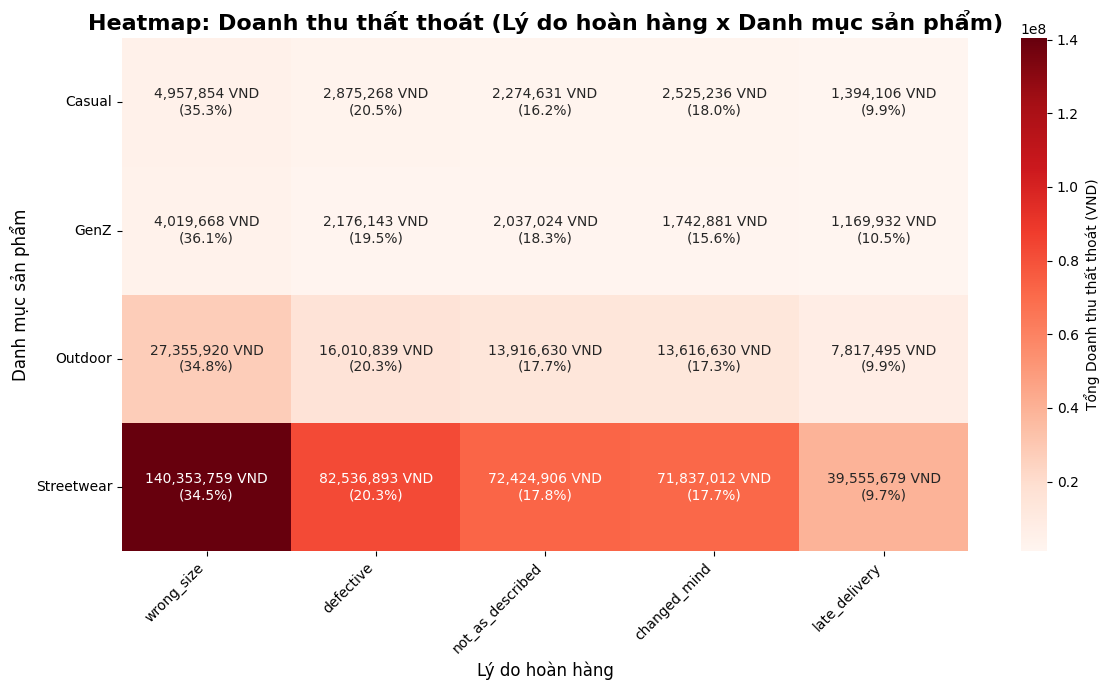

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Hợp nhất dữ liệu để có refund_amount, return_reason và category
# Bắt đầu từ fact_returns, nối với dim_product[['product_id', 'category']] để lấy category
revenue_lost_by_reason_category = pd.merge(fact_returns, dim_product[['product_id', 'category']], on='product_id', how='left')

# Phân nhóm theo danh mục và lý do trả hàng, tính tổng số tiền hoàn lại.
revenue_lost_by_reason_category_agg = revenue_lost_by_reason_category.groupby(['category', 'return_reason'])['refund_amount'].sum().reset_index()

heatmap_data = revenue_lost_by_reason_category_agg.pivot_table(index='category', columns='return_reason', values='refund_amount', fill_value=0)
ordered_reasons = ['wrong_size', 'defective', 'not_as_described', 'changed_mind', 'late_delivery']
heatmap_data = heatmap_data[ordered_reasons]

# Tính toán tỷ lệ phần trăm phần chú thích
total_refund_per_category = heatmap_data.sum(axis=1)
percentage_data = heatmap_data.div(total_refund_per_category, axis=0) * 100
annot_values = []
for r_idx in heatmap_data.index:
    row_values = []
    for c_idx in heatmap_data.columns:
        value = heatmap_data.loc[r_idx, c_idx]
        percentage = percentage_data.loc[r_idx, c_idx]
        if value > 0:
            row_values.append(f'{value:,.0f} VND\n({percentage:.1f}%)')
        else:
            row_values.append('')
    annot_values.append(row_values)

annot_data = pd.DataFrame(annot_values, index=heatmap_data.index, columns=heatmap_data.columns, dtype=object)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt="",
    cmap='Reds',
    cbar_kws={'label': 'Tổng Doanh thu thất thoát (VND)'}
)

plt.title('Heatmap: Doanh thu thất thoát (Lý do hoàn hàng x Danh mục sản phẩm)', fontsize=16, fontweight='bold')
plt.xlabel('Lý do hoàn hàng', fontsize=12)
plt.ylabel('Danh mục sản phẩm', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

--- Phân tích Pareto: Doanh thu thất thoát do hoàn hàng theo danh mục ---
     category  total_refund_amount  percentage  cumulative_percentage
0  Streetwear         4.067082e+08       79.65                  79.65
1     Outdoor         7.871751e+07       15.42                  95.07
2      Casual         1.402709e+07        2.75                  97.82
3        GenZ         1.114565e+07        2.18                 100.00
----------------------------------------------------------------------


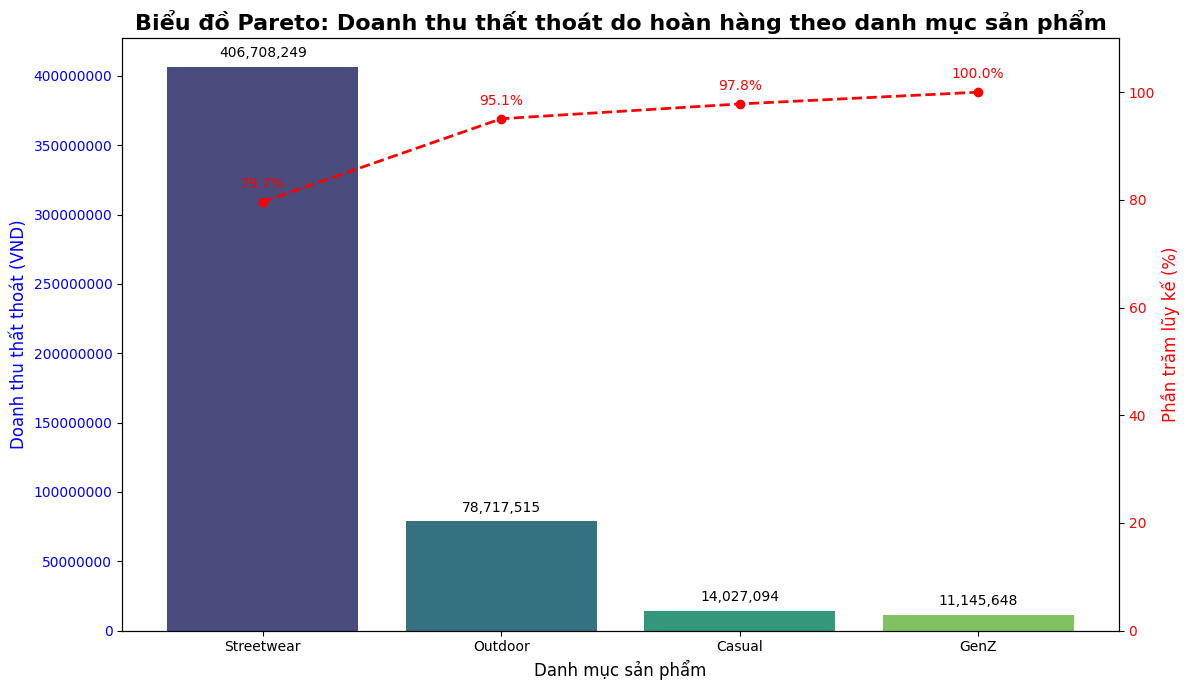

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Hợp nhất dữ liệu để tính tổng doanh thu thất thoát (refund_amount) theo từng danh mục
# `fact_returns` và `dim_product` đã có sẵn từ các bước trước
returns_with_category = pd.merge(fact_returns, dim_product[['product_id', 'category']], on='product_id', how='left')

# Group by category and sum the refund_amount
refund_by_category = returns_with_category.groupby('category')['refund_amount'].sum().reset_index()
refund_by_category.rename(columns={'refund_amount': 'total_refund_amount'}, inplace=True)

# 2. Sắp xếp các danh mục theo tổng doanh thu thất thoát giảm dần
pareto_data = refund_by_category.sort_values(by='total_refund_amount', ascending=False).reset_index(drop=True)

# 3. Tính toán phần trăm và phần trăm lũy kế
pareto_data['percentage'] = (pareto_data['total_refund_amount'] / pareto_data['total_refund_amount'].sum()) * 100
pareto_data['cumulative_percentage'] = pareto_data['percentage'].cumsum()

print("--- Phân tích Pareto: Doanh thu thất thoát do hoàn hàng theo danh mục ---")
print(pareto_data.round(2))
print("-" * 70)

# 4. Vẽ biểu đồ Pareto
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart cho tổng doanh thu thất thoát
sns.barplot(
    x='category',
    y='total_refund_amount',
    data=pareto_data,
    palette='viridis',
    ax=ax1,
    hue='category',
    legend=False
)

ax1.set_xlabel('Danh mục sản phẩm', fontsize=12)
ax1.set_ylabel('Doanh thu thất thoát (VND)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Biểu đồ Pareto: Doanh thu thất thoát do hoàn hàng theo danh mục sản phẩm', fontsize=16, fontweight='bold')
ax1.ticklabel_format(style='plain', axis='y') # Tắt định dạng khoa học cho trục y

# Line chart cho phần trăm lũy kế
ax2 = ax1.twinx() # Tạo trục y thứ hai chia sẻ trục x
ax2.plot(
    pareto_data['category'],
    pareto_data['cumulative_percentage'],
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Phần trăm lũy kế'
)

ax2.set_ylabel('Phần trăm lũy kế (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # Đặt giới hạn cho trục y của phần trăm lũy kế
ax2.grid(False)

# Hiển thị phần trăm lũy kế trên đường line
for index, row in pareto_data.iterrows():
    ax2.annotate(
        f'{row["cumulative_percentage"]:.1f}%',
        (row['category'], row['cumulative_percentage']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        color='red',
        fontsize=10
    )

# Hiển thị giá trị trên các cột bar
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

--- Tỷ lệ mua lại theo danh mục sản phẩm ---
     category  total_customers  num_repurchasers  repurchase_rate
3  Streetwear            77215             54327            70.36
2     Outdoor            59121             35886            60.70
1        GenZ            23350              7881            33.75
0      Casual            17136              4309            25.15
--------------------------------------------------


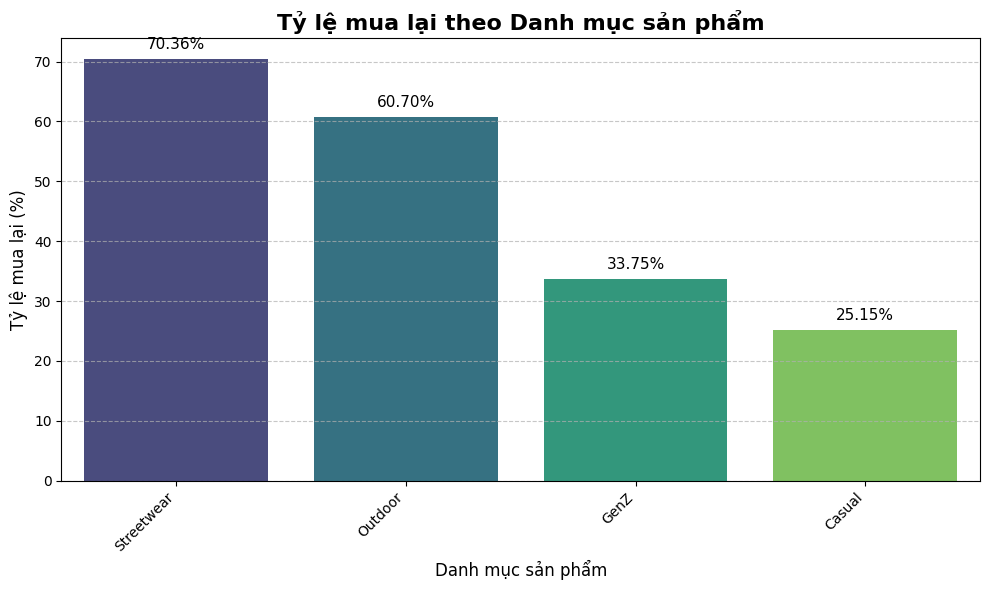

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Merge relevant dataframes to link customer_id with product category
# Start with order_items to get product_id and order_id
repurchase_data = pd.merge(df_order_items, df_order[['order_id', 'customer_id']], on='order_id', how='left')

# Now merge with dim_product to get the category
repurchase_data = pd.merge(repurchase_data, dim_product[['product_id', 'category']], on='product_id', how='left')

# Drop rows where category might be missing (if any product_id didn't match)
repurchase_data.dropna(subset=['category'], inplace=True)

# 2. Count unique orders per customer per category
# This creates a Series where the index is (customer_id, category) and values are the count of unique orders
customer_category_orders = repurchase_data.groupby(['customer_id', 'category'])['order_id'].nunique().reset_index()
customer_category_orders.rename(columns={'order_id': 'unique_orders'}, inplace=True)

# 3. Identify repurchasers: customers who have more than 1 unique order in a category
repurchasers_by_category = customer_category_orders[customer_category_orders['unique_orders'] > 1]

# 4. Calculate the number of unique customers for each category (total customers who bought from that category)
total_unique_customers_per_category = repurchase_data.groupby('category')['customer_id'].nunique().reset_index()
total_unique_customers_per_category.rename(columns={'customer_id': 'total_customers'}, inplace=True)

# 5. Calculate the number of repurchasing customers for each category
num_repurchasers_per_category = repurchasers_by_category.groupby('category')['customer_id'].nunique().reset_index()
num_repurchasers_per_category.rename(columns={'customer_id': 'num_repurchasers'}, inplace=True)

# 6. Merge to calculate repurchase rate
repurchase_rate_df = pd.merge(
    total_unique_customers_per_category,
    num_repurchasers_per_category,
    on='category',
    how='left'
)

# Fill NaN with 0 for categories with no repurchasers
repurchase_rate_df['num_repurchasers'] = repurchase_rate_df['num_repurchasers'].fillna(0)

# Calculate repurchase rate
repurchase_rate_df['repurchase_rate'] = (repurchase_rate_df['num_repurchasers'] / repurchase_rate_df['total_customers']) * 100

# Sort for better visualization
repurchase_rate_df = repurchase_rate_df.sort_values(by='repurchase_rate', ascending=False)

print("--- Tỷ lệ mua lại theo danh mục sản phẩm ---")
print(repurchase_rate_df.round(2))
print("-" * 50)

# 7. Visualize the repurchase rate by category
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='category',
    y='repurchase_rate',
    data=repurchase_rate_df,
    palette='viridis',
    hue='category',
    legend=False
)

plt.title('Tỷ lệ mua lại theo Danh mục sản phẩm', fontsize=16, fontweight='bold')
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Tỷ lệ mua lại (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Phân tích mối liên hệ giữa Chương trình Khuyến mãi và Tỷ lệ hoàn trả sản phẩm

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Chuẩn bị dữ liệu bán hàng với thông tin khuyến mãi
# Lọc các giao dịch có promo_id
sales_with_promo = fact_sales.dropna(subset=['promo_id']).copy()

# Group by promo_id để lấy tổng số lượng sản phẩm đã bán trong mỗi khuyến mãi
total_sold_by_promo = sales_with_promo.groupby('promo_id')['quantity'].sum().reset_index()
total_sold_by_promo.rename(columns={'quantity': 'total_units_sold'}, inplace=True)

# 2. Chuẩn bị dữ liệu trả hàng với thông tin khuyến mãi
# Hợp nhất df_returns với fact_sales để lấy promo_id cho các sản phẩm trả lại
# Sử dụng fact_sales thay vì df_order_items để đảm bảo thông tin promo_id
returns_with_promo = pd.merge(fact_returns, fact_sales[['order_id', 'product_id', 'promo_id']],
                              on=['order_id', 'product_id'], how='left')

# Lọc các trả hàng có promo_id (chỉ xét các sản phẩm được mua trong chương trình khuyến mãi)
returns_with_promo = returns_with_promo.dropna(subset=['promo_id'])

# Group by promo_id để lấy tổng số lượng sản phẩm đã trả lại trong mỗi khuyến mãi
total_returned_by_promo = returns_with_promo.groupby('promo_id')['return_quantity'].sum().reset_index()
total_returned_by_promo.rename(columns={'return_quantity': 'total_units_returned'}, inplace=True)

# 3. Hợp nhất dữ liệu bán và trả hàng theo khuyến mãi và tính tỷ lệ hoàn trả
promo_return_analysis = pd.merge(total_sold_by_promo, total_returned_by_promo,
                                 on='promo_id', how='left')

# Xử lý các khuyến mãi không có sản phẩm trả lại (fillna với 0)
promo_return_analysis['total_units_returned'] = promo_return_analysis['total_units_returned'].fillna(0)

# Tính toán tỷ lệ hoàn trả
promo_return_analysis['return_rate'] = (promo_return_analysis['total_units_returned'] / promo_return_analysis['total_units_sold']) * 100

# Hợp nhất với dim_promotion để có tên khuyến mãi
promo_return_analysis = pd.merge(promo_return_analysis, dim_promotion[['promo_id', 'promo_name']],
                                 on='promo_id', how='left')

# Sắp xếp để dễ đọc hơn
promo_return_analysis = promo_return_analysis.sort_values(by='return_rate', ascending=False).reset_index(drop=True)

print("--- Phân tích Tỷ lệ Hoàn trả theo Chương trình Khuyến mãi ---")
print(promo_return_analysis.round(2))
print("-" * 80)


--- Phân tích Tỷ lệ Hoàn trả theo Chương trình Khuyến mãi ---
      promo_id  total_units_sold  total_units_returned  return_rate  \
0   PROMO-0026              8460                   355         4.20   
1   PROMO-0006             12607                   515         4.09   
2   PROMO-0001             38351                  1475         3.85   
3   PROMO-0010             50940                  1943         3.81   
4   PROMO-0049             11631                   436         3.75   
5   PROMO-0003             28142                  1050         3.73   
6   PROMO-0017             39743                  1476         3.71   
7   PROMO-0025             24246                   898         3.70   
8   PROMO-0022             33699                  1248         3.70   
9   PROMO-0048             13791                   501         3.63   
10  PROMO-0023             24470                   880         3.60   
11  PROMO-0011             42908                  1530         3.57   
12  PROMO-0020 

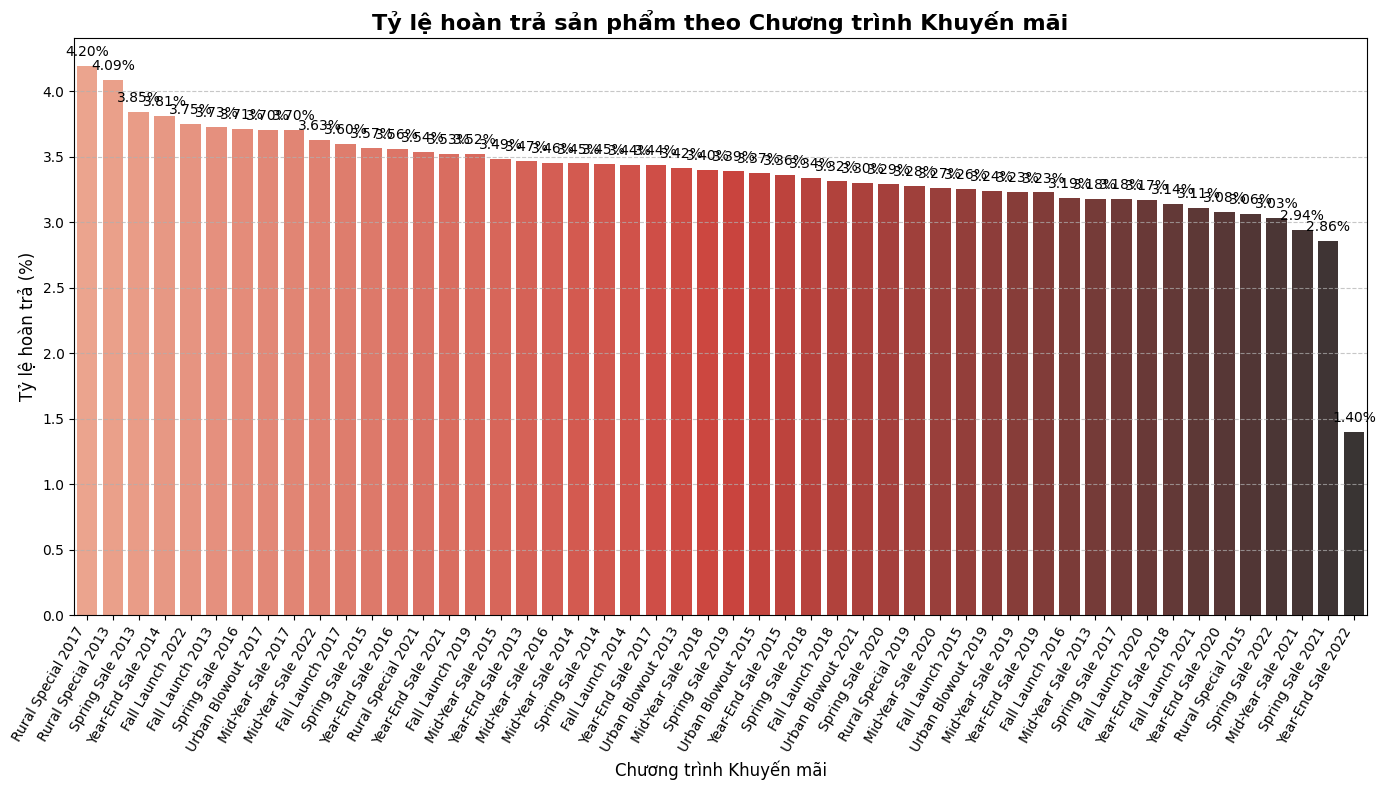

In [28]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(
    x='promo_name',
    y='return_rate',
    data=promo_return_analysis,
    palette='Reds_d',
    ax=ax,
    hue='promo_name',
    legend=False
)

plt.title('Tỷ lệ hoàn trả sản phẩm theo Chương trình Khuyến mãi', fontsize=16, fontweight='bold')
plt.xlabel('Chương trình Khuyến mãi', fontsize=12)
plt.ylabel('Tỷ lệ hoàn trả (%)', fontsize=12)
plt.xticks(rotation=60, ha='right') # Xoay nhãn x để dễ đọc hơn
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm giá trị phần trăm lên trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


### Phân tích Tỷ lệ Hoàn trả theo Chương trình Khuyến mãi và Lý do Hoàn trả

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse sales_with_promo and total_sold_by_promo from previous cell (8257c480)
# If not run, ensure the previous cell is executed to define these dataframes.
# sales_with_promo = fact_sales.dropna(subset=['promo_id']).copy()
# total_sold_by_promo = sales_with_promo.groupby('promo_id')['quantity'].sum().reset_index()
# total_sold_by_promo.rename(columns={'quantity': 'total_units_sold'}, inplace=True)

# 1. Chuẩn bị dữ liệu trả hàng với thông tin khuyến mãi và lý do
# returns_with_promo (from previous cell 8257c480) already contains promo_id and return_reason
returns_by_promo_reason = returns_with_promo.groupby(['promo_id', 'return_reason'])['return_quantity'].sum().reset_index()
returns_by_promo_reason.rename(columns={'return_quantity': 'total_units_returned_by_reason'}, inplace=True)

# 2. Hợp nhất dữ liệu trả hàng theo lý do với tổng số lượng bán được của mỗi khuyến mãi
promo_return_rate_by_reason = pd.merge(returns_by_promo_reason, total_sold_by_promo, on='promo_id', how='left')

# Xử lý các khuyến mãi không có sản phẩm trả lại cho một lý do cụ thể (fillna với 0)
promo_return_rate_by_reason['total_units_returned_by_reason'] = promo_return_rate_by_reason['total_units_returned_by_reason'].fillna(0)

# 3. Tính toán tỷ lệ hoàn trả cho mỗi lý do trong từng chương trình khuyến mãi
promo_return_rate_by_reason['return_rate'] = (
promo_return_rate_by_reason['total_units_returned_by_reason'] / promo_return_rate_by_reason['total_units_sold']) * 100

# 4. Hợp nhất với dim_promotion để có tên khuyến mãi
promo_return_rate_by_reason = pd.merge(promo_return_rate_by_reason, dim_promotion[['promo_id', 'promo_name']],
                                         on='promo_id', how='left')

# Sắp xếp và làm sạch dữ liệu để hiển thị
promo_return_rate_by_reason_pivot = promo_return_rate_by_reason.pivot_table(
    index='promo_name', columns='return_reason', values='return_rate', fill_value=0
)

# Optional: Sắp xếp các lý do hoàn hàng để nhất quán
ordered_reasons = ['wrong_size', 'defective', 'not_as_described', 'changed_mind', 'late_delivery']
promo_return_rate_by_reason_pivot = promo_return_rate_by_reason_pivot[ordered_reasons]

print("--- Tỷ lệ hoàn trả (%) theo Chương trình Khuyến mãi và Lý do Hoàn trả ---")
print(promo_return_rate_by_reason_pivot.round(2))
print("-" * 80)


--- Tỷ lệ hoàn trả (%) theo Chương trình Khuyến mãi và Lý do Hoàn trả ---
return_reason       wrong_size  defective  not_as_described  changed_mind  \
promo_name                                                                  
Fall Launch 2013          1.45       0.64              0.76          0.53   
Fall Launch 2014          1.03       0.75              0.62          0.69   
Fall Launch 2015          1.09       0.66              0.65          0.48   
Fall Launch 2016          1.12       0.66              0.59          0.49   
Fall Launch 2017          1.24       0.83              0.54          0.55   
Fall Launch 2018          0.90       0.67              0.62          0.77   
Fall Launch 2019          1.11       0.75              0.54          0.77   
Fall Launch 2020          1.15       0.98              0.48          0.36   
Fall Launch 2021          1.01       0.69              0.78          0.43   
Fall Launch 2022          1.38       0.60              0.59          0.67   
Mi

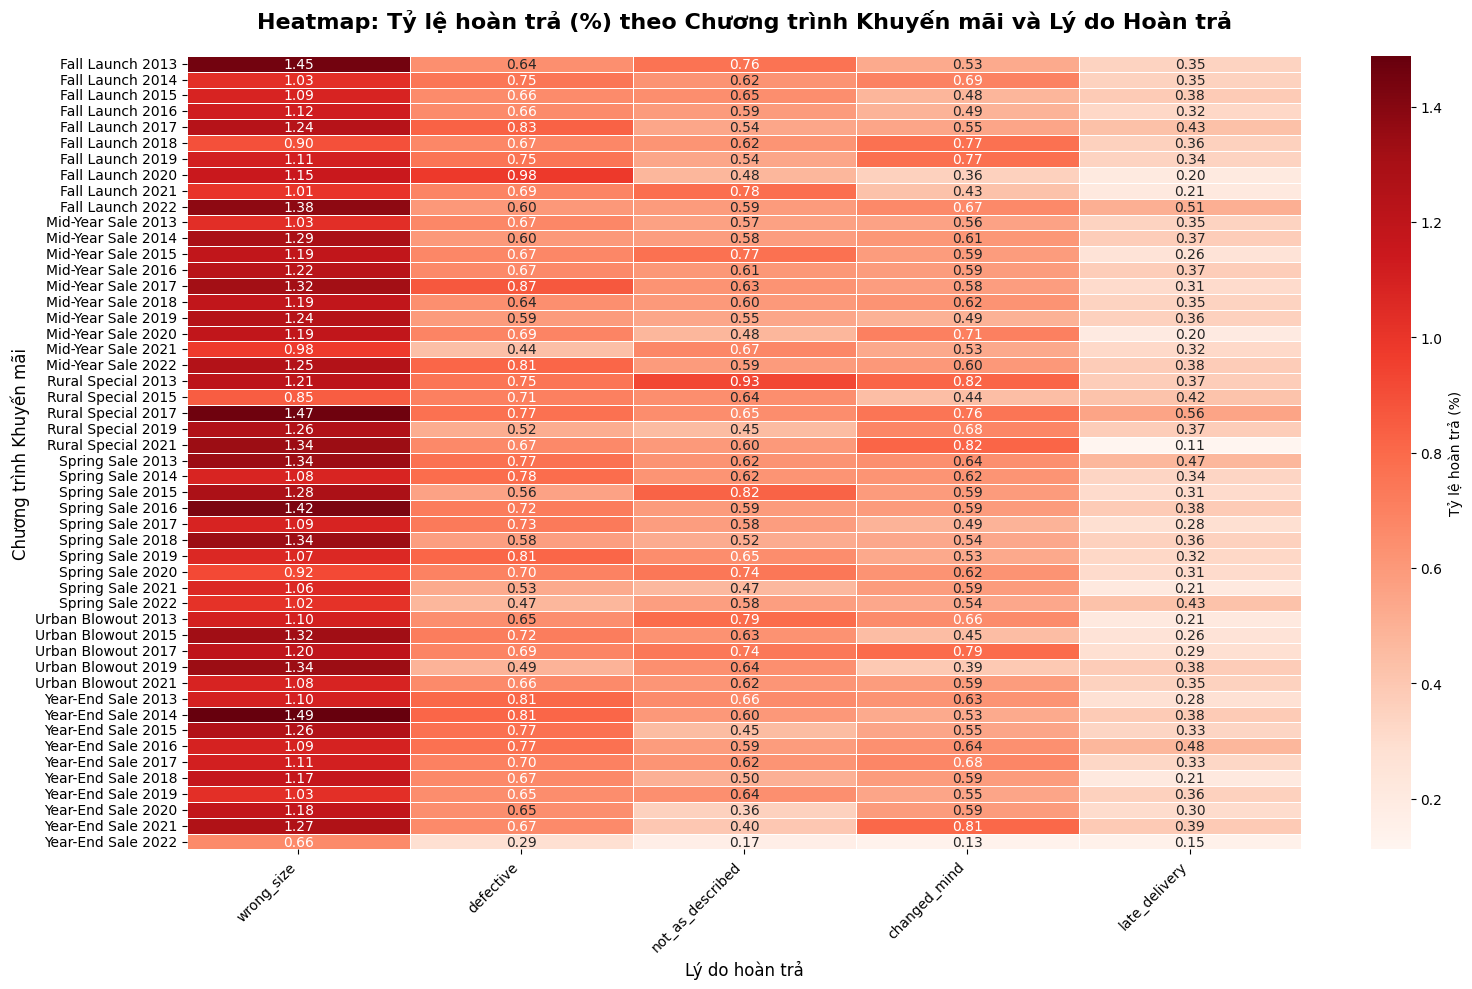

In [30]:
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    promo_return_rate_by_reason_pivot,
    annot=True,     # Hiển thị giá trị trên heatmap
    fmt=".2f",      # Định dạng số thập phân 2 chữ số
    cmap="Reds",    # Sử dụng bảng màu đỏ
    linewidths=.5,  # Đường kẻ giữa các ô
    cbar_kws={'label': 'Tỷ lệ hoàn trả (%)'}
)

plt.title('Heatmap: Tỷ lệ hoàn trả (%) theo Chương trình Khuyến mãi và Lý do Hoàn trả',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lý do hoàn trả', fontsize=12)
plt.ylabel('Chương trình Khuyến mãi', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Phân tích tác động của khuyến mãi lên Dòng sản phẩm (Category)

Biểu đồ này sẽ thể hiện cách các chương trình khuyến mãi khác nhau ảnh hưởng đến doanh thu và số lượng bán ra của từng danh mục sản phẩm, giúp xác định những danh mục nào hoạt động tốt nhất dưới các loại khuyến mãi cụ thể.

--- Doanh thu và Số lượng bán theo Chương trình Khuyến mãi và Danh mục sản phẩm ---
           promo_name    category  total_revenue  total_quantity  \
104  Spring Sale 2017  Streetwear   1.484705e+08           25392   
103  Spring Sale 2017     Outdoor   2.512085e+07           12530   
101  Spring Sale 2017      Casual   3.870688e+06            1171   
102  Spring Sale 2017        GenZ   2.323954e+06            1278   
96   Spring Sale 2015  Streetwear   1.402873e+08           24050   
95   Spring Sale 2015     Outdoor   2.999769e+07           16314   
93   Spring Sale 2015      Casual   3.385672e+06            1047   
94   Spring Sale 2015        GenZ   2.551267e+06            1497   
100  Spring Sale 2016  Streetwear   1.402071e+08           23706   
99   Spring Sale 2016     Outdoor   2.487311e+07           13557   

     promo_total_revenue  total_revenue_billion  
104         1.797860e+08                   0.15  
103         1.797860e+08                   0.03  
101         1.797

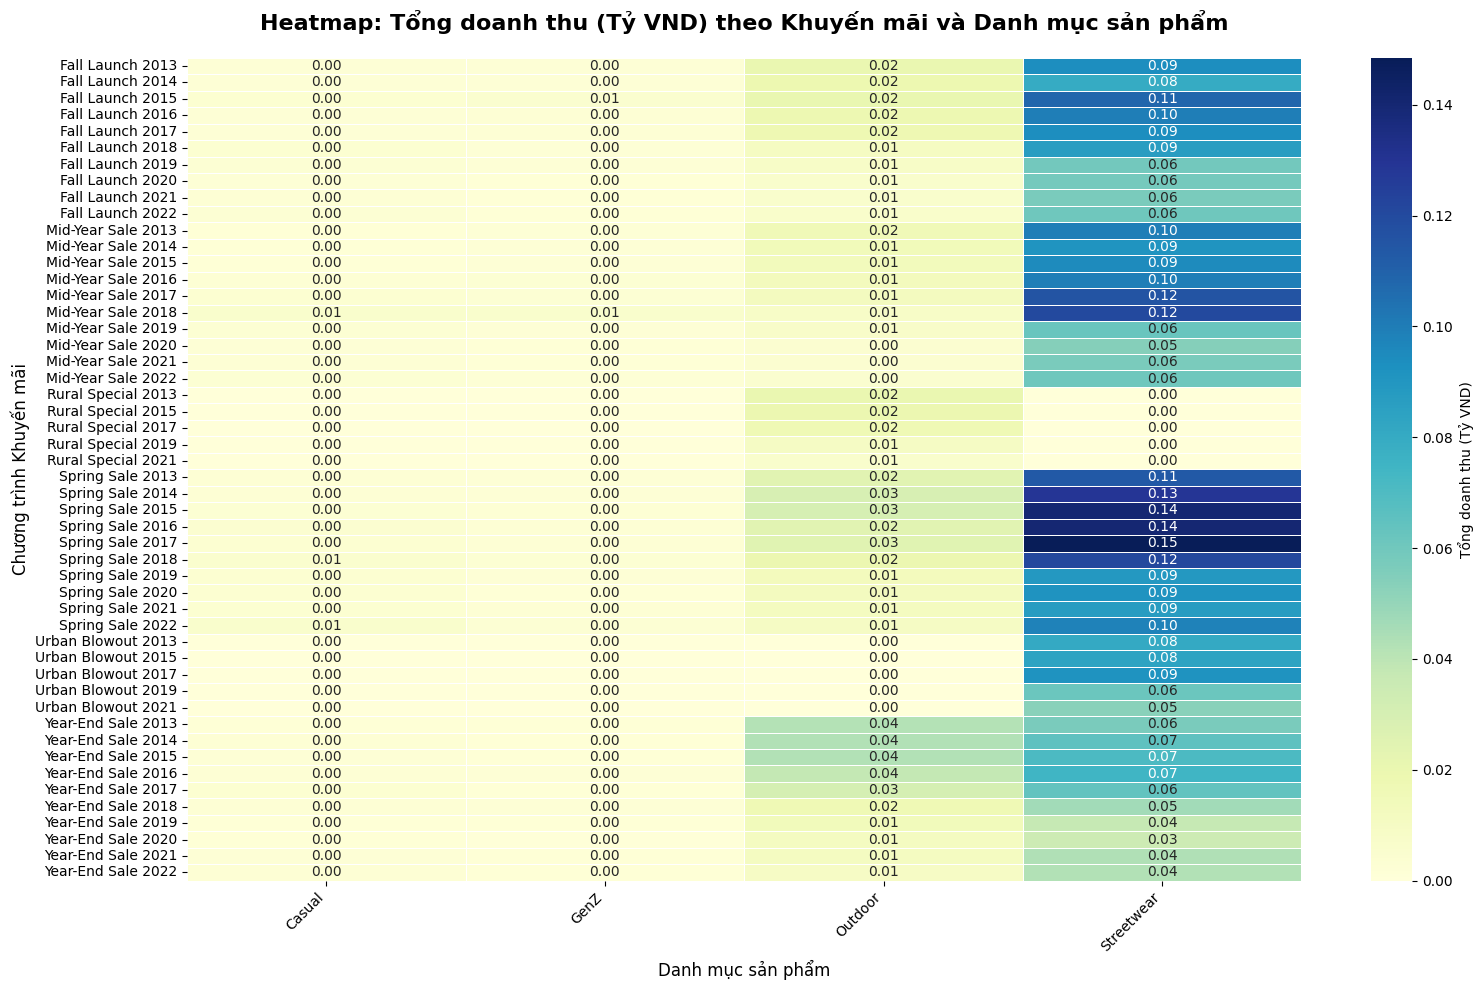

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Hợp nhất fact_sales với dim_product và dim_promotion để có category và promo_name
promo_category_sales = pd.merge(fact_sales, dim_product[['product_id', 'category']], on='product_id', how='left')
promo_category_sales = pd.merge(promo_category_sales, dim_promotion[['promo_id', 'promo_name']], on='promo_id', how='left')

# Lọc chỉ các giao dịch có khuyến mãi
promo_category_sales = promo_category_sales.dropna(subset=['promo_id', 'category'])

# 2. Tổng hợp doanh thu và số lượng bán theo khuyến mãi và danh mục
agg_promo_category = promo_category_sales.groupby(['promo_name', 'category']).agg(
    total_revenue=('Revenue', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

# Tính tổng doanh thu/số lượng theo khuyến mãi để sắp xếp
agg_promo_category['promo_total_revenue'] = agg_promo_category.groupby('promo_name')['total_revenue'].transform('sum')
agg_promo_category = agg_promo_category.sort_values(by=['promo_total_revenue', 'total_revenue'], ascending=[False, False])

# Chuyển đổi doanh thu sang tỷ VND để dễ đọc
agg_promo_category['total_revenue_billion'] = agg_promo_category['total_revenue'] / 1_000_000_000

print("--- Doanh thu và Số lượng bán theo Chương trình Khuyến mãi và Danh mục sản phẩm ---")
print(agg_promo_category.round(2).head(10))
print("-" * 80)

# 3. Tạo biểu đồ Heatmap cho Doanh thu
pivot_revenue = agg_promo_category.pivot_table(index='promo_name', columns='category', values='total_revenue_billion', fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_revenue,
    annot=True,
    fmt=".2f", # Định dạng 2 chữ số thập phân
    cmap="YlGnBu", # Bảng màu xanh lá cây sang xanh dương
    linewidths=.5,
    cbar_kws={'label': 'Tổng doanh thu (Tỷ VND)'}
)
plt.title('Heatmap: Tổng doanh thu (Tỷ VND) theo Khuyến mãi và Danh mục sản phẩm', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Chương trình Khuyến mãi', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Phân tích tác động của khuyến mãi lên Sản phẩm cụ thể

/tmp/ipykernel_2343/3405438195.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_products = df.groupby('promo_name').apply(


--- Top 5 Sản phẩm bán chạy nhất trong mỗi Chương trình Khuyến mãi ---
          promo_name       product_name    category  total_revenue  \
0   Fall Launch 2013  HanoiStreet RP-74     Outdoor      312967.04   
1   Fall Launch 2013  HanoiStreet RP-73     Outdoor      306395.74   
2   Fall Launch 2013  HanoiStreet RP-21     Outdoor     1436870.38   
3   Fall Launch 2013  HanoiStreet RP-22     Outdoor     1331488.72   
4   Fall Launch 2013  HanoiStreet UM-10  Streetwear     3850938.66   
5   Fall Launch 2014  HanoiStreet RP-80     Outdoor      541331.23   
6   Fall Launch 2014  HanoiStreet RP-79     Outdoor      525458.03   
7   Fall Launch 2014   SaigonFlex UC-69  Streetwear     2219820.55   
8   Fall Launch 2014  HanoiStreet UC-56  Streetwear     1318998.03   
9   Fall Launch 2014   SaigonFlex UM-80  Streetwear     3728604.80   
10  Fall Launch 2015   VietMotion YY-05        GenZ      750650.91   
11  Fall Launch 2015  HanoiStreet RP-79     Outdoor      432483.90   
12  Fall Launch 201

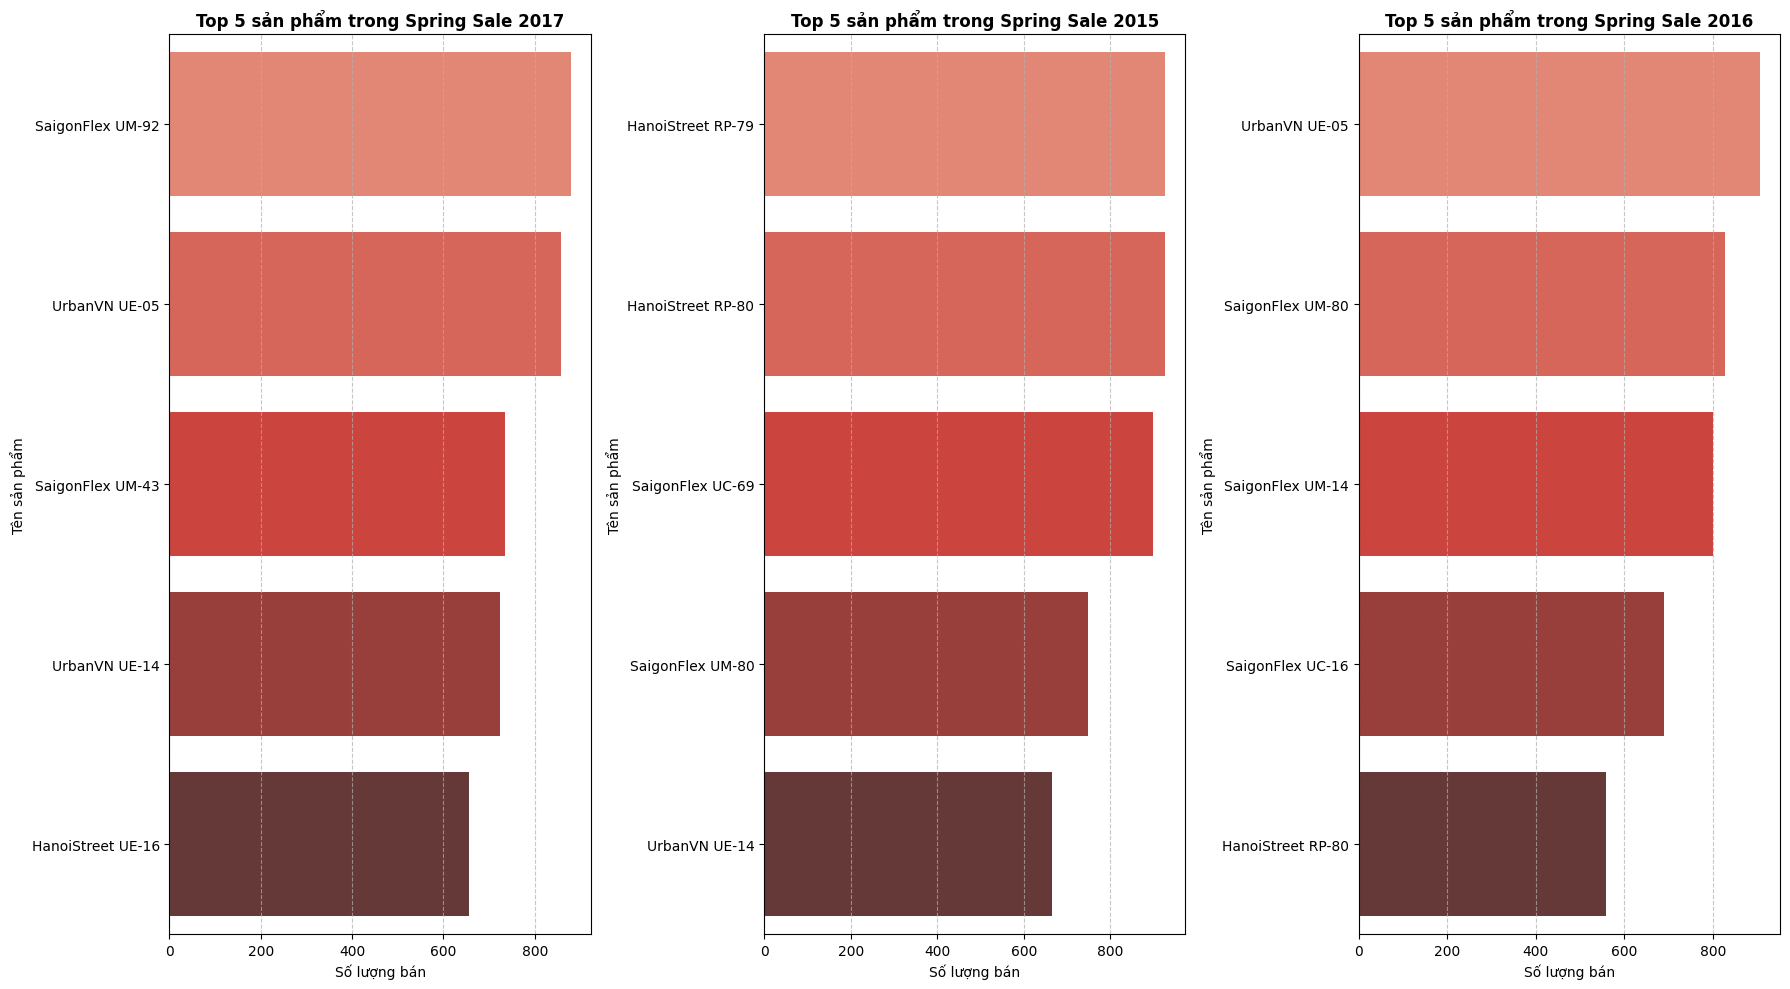

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lấy top N sản phẩm bán chạy nhất trong mỗi khuyến mãi
def get_top_n_products_per_promo(df, n=5):
    # Đảm bảo promo_name và product_name tồn tại
    if 'promo_name' not in df.columns or 'product_name' not in df.columns:
        raise ValueError("DataFrame must contain 'promo_name' and 'product_name' columns.")

    top_products = df.groupby('promo_name').apply(
        lambda x: x.sort_values(by='total_quantity', ascending=False).head(n)
    ).reset_index(drop=True)
    return top_products

# Hợp nhất dữ liệu để có thông tin sản phẩm và khuyến mãi
promo_product_sales = pd.merge(fact_sales, dim_product[['product_id', 'product_name', 'category']], on='product_id', how='left')
promo_product_sales = pd.merge(promo_product_sales, dim_promotion[['promo_id', 'promo_name']], on='promo_id', how='left')

# Lọc chỉ các giao dịch có khuyến mãi và sản phẩm rõ ràng
promo_product_sales = promo_product_sales.dropna(subset=['promo_id', 'product_name'])

# Tổng hợp doanh thu và số lượng bán theo khuyến mãi và sản phẩm
agg_promo_product = promo_product_sales.groupby(['promo_name', 'product_name', 'category']).agg(
    total_revenue=('Revenue', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

# Lấy top 5 sản phẩm bán chạy nhất trong mỗi khuyến mãi
top_5_products_per_promo = get_top_n_products_per_promo(agg_promo_product, n=5)

print("--- Top 5 Sản phẩm bán chạy nhất trong mỗi Chương trình Khuyến mãi ---")
print(top_5_products_per_promo.round(2).head(20)) # Hiển thị nhiều hơn để có cái nhìn tổng quan
print("-" * 80)

# Tạo biểu đồ Bar cho Top N sản phẩm theo khuyến mãi (chọn một vài khuyến mãi tiêu biểu)
# Chọn 3 khuyến mãi có doanh thu cao nhất để hiển thị
top_3_promos_by_revenue = agg_promo_category.groupby('promo_name')['total_revenue'].sum().nlargest(3).index

plt.figure(figsize=(18, 10))
for i, promo in enumerate(top_3_promos_by_revenue):
    plt.subplot(1, 3, i + 1)
    data_to_plot = top_5_products_per_promo[top_5_products_per_promo['promo_name'] == promo]
    sns.barplot(x='total_quantity', y='product_name', data=data_to_plot, palette='Reds_d', hue='product_name', legend=False)
    plt.title(f'Top 5 sản phẩm trong {promo}', fontsize=12, fontweight='bold')
    plt.xlabel('Số lượng bán', fontsize=10)
    plt.ylabel('Tên sản phẩm', fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Phân tích tác động của khuyến mãi lên Web Traffic

Phần này đánh giá mức độ ảnh hưởng của các chương trình khuyến mãi đến hành vi truy cập của người dùng trên website, bao gồm số lượng phiên (sessions), khách truy cập duy nhất (unique visitors) và lượt xem trang (page views).

--- Phân tích Web Traffic trong thời gian Khuyến mãi ---
      promo_id          promo_name start_date   end_date  total_sessions  \
44  PROMO-0045  Urban Blowout 2021 2021-07-30 2021-09-02         1302720   
46  PROMO-0047    Spring Sale 2022 2022-03-18 2022-04-17         1237770   
40  PROMO-0041    Spring Sale 2021 2021-03-18 2021-04-17         1202511   
36  PROMO-0037    Spring Sale 2020 2020-03-18 2020-04-17         1199049   
34  PROMO-0035  Urban Blowout 2019 2019-07-30 2019-09-02         1181796   
47  PROMO-0048  Mid-Year Sale 2022 2022-06-23 2022-07-22         1122903   
30  PROMO-0031    Spring Sale 2019 2019-03-18 2019-04-17         1105570   
24  PROMO-0025  Urban Blowout 2017 2017-07-30 2017-09-02         1094512   
41  PROMO-0042  Mid-Year Sale 2021 2021-06-23 2021-07-22         1085484   
37  PROMO-0038  Mid-Year Sale 2020 2020-06-23 2020-07-22         1040085   

    total_unique_visitors  total_page_views  avg_bounce_rate  
44                1002899           5610009

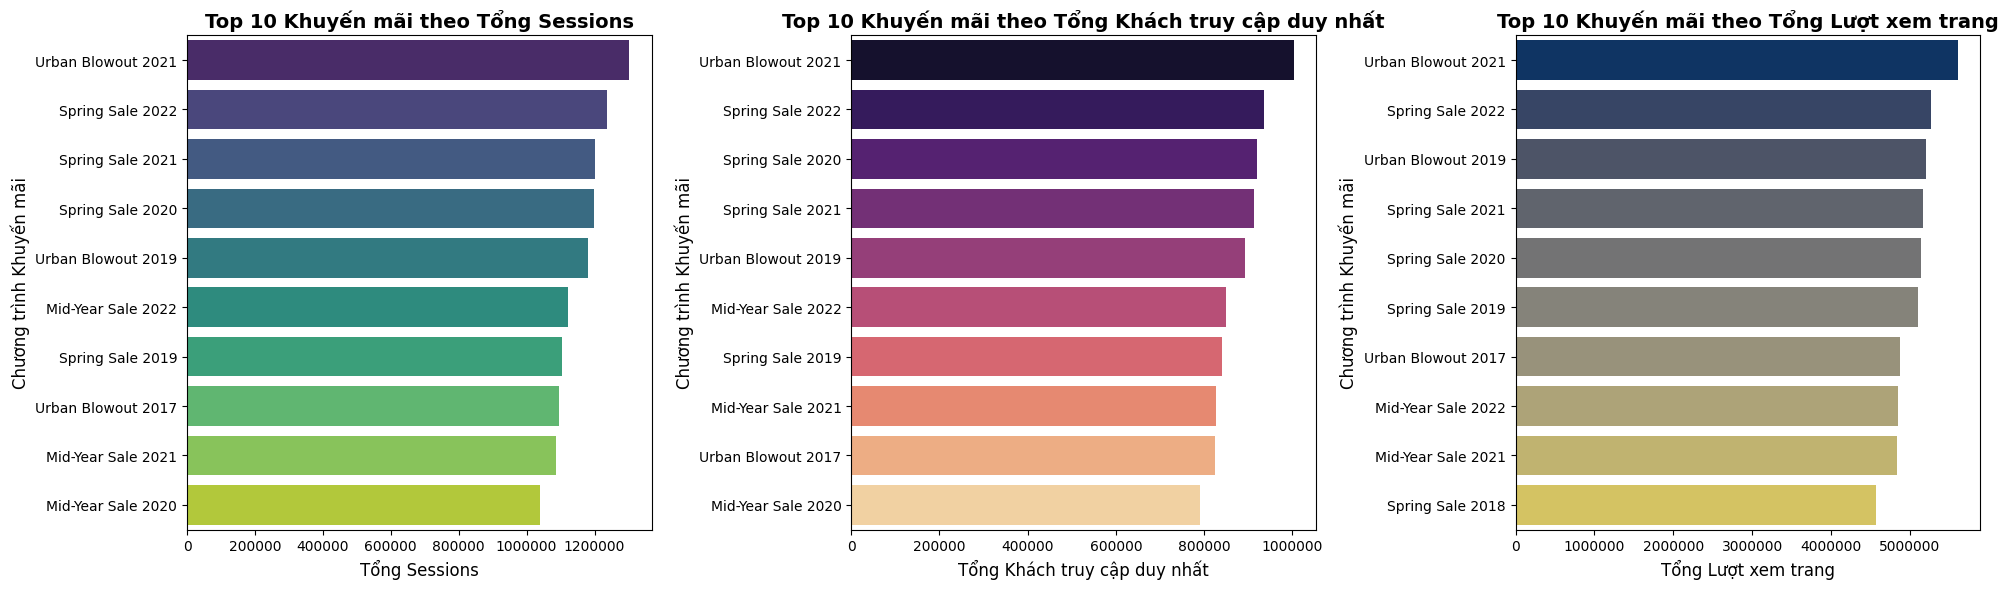

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Đảm bảo cột 'date' trong df_web_traffic là datetime object
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])

# 2. Xử lý df_promotions để có start_date và end_date dưới dạng datetime
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

# 3. Tạo một DataFrame để lưu trữ dữ liệu traffic trong thời gian khuyến mãi
promotion_traffic_data = []

for index, promo_row in df_promotions.iterrows():
    promo_id = promo_row['promo_id']
    promo_name = promo_row['promo_name']
    start_date = promo_row['start_date']
    end_date = promo_row['end_date']

    # Lọc dữ liệu web traffic trong khoảng thời gian khuyến mãi
    traffic_during_promo = df_web_traffic[
        (df_web_traffic['date'] >= start_date) &
        (df_web_traffic['date'] <= end_date)
    ]

    if not traffic_during_promo.empty:
        # Tính tổng các chỉ số traffic trong thời gian khuyến mãi
        total_sessions = traffic_during_promo['sessions'].sum()
        total_unique_visitors = traffic_during_promo['unique_visitors'].sum()
        total_page_views = traffic_during_promo['page_views'].sum()
        avg_bounce_rate = traffic_during_promo['bounce_rate'].mean()

        promotion_traffic_data.append({
            'promo_id': promo_id,
            'promo_name': promo_name,
            'start_date': start_date,
            'end_date': end_date,
            'total_sessions': total_sessions,
            'total_unique_visitors': total_unique_visitors,
            'total_page_views': total_page_views,
            'avg_bounce_rate': avg_bounce_rate
        })

promo_traffic_df = pd.DataFrame(promotion_traffic_data)

print("--- Phân tích Web Traffic trong thời gian Khuyến mãi ---")
print(promo_traffic_df.sort_values(by='total_sessions', ascending=False).round(2).head(10))
print("-" * 80)

# 4. Trực quan hóa Top N khuyến mãi theo từng chỉ số traffic

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Top 10 Promotions by Total Sessions
sns.barplot(x='total_sessions', y='promo_name', data=promo_traffic_df.nlargest(10, 'total_sessions'), ax=axes[0], palette='viridis', hue='promo_name', legend=False)
axes[0].set_title('Top 10 Khuyến mãi theo Tổng Sessions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tổng Sessions', fontsize=12)
axes[0].set_ylabel('Chương trình Khuyến mãi', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='x')

# Top 10 Promotions by Total Unique Visitors
sns.barplot(x='total_unique_visitors', y='promo_name', data=promo_traffic_df.nlargest(10, 'total_unique_visitors'), ax=axes[1], palette='magma', hue='promo_name', legend=False)
axes[1].set_title('Top 10 Khuyến mãi theo Tổng Khách truy cập duy nhất', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tổng Khách truy cập duy nhất', fontsize=12)
axes[1].set_ylabel('Chương trình Khuyến mãi', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='x')

# Top 10 Promotions by Total Page Views
sns.barplot(x='total_page_views', y='promo_name', data=promo_traffic_df.nlargest(10, 'total_page_views'), ax=axes[2], palette='cividis', hue='promo_name', legend=False)
axes[2].set_title('Top 10 Khuyến mãi theo Tổng Lượt xem trang', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tổng Lượt xem trang', fontsize=12)
axes[2].set_ylabel('Chương trình Khuyến mãi', fontsize=12)
axes[2].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

### Phân tích Web Traffic: Trước, Trong và Sau Chương trình Khuyến mãi

Phần này đánh giá sự thay đổi trong hành vi truy cập web của người dùng (số phiên, khách truy cập duy nhất, lượt xem trang) trong ba giai đoạn: trước khi khuyến mãi diễn ra, trong thời gian khuyến mãi, và sau khi khuyến mãi kết thúc. Mỗi giai đoạn 'trước' và 'sau' được định nghĩa có cùng độ dài với thời gian diễn ra khuyến mãi.

--- So sánh Web Traffic và Doanh số Trước, Trong và Sau Khuyến mãi (Top 15 hàng đầu) ---
      promo_id          promo_name  period  total_sessions  \
0   PROMO-0001    Spring Sale 2013  Before          546327   
1   PROMO-0001    Spring Sale 2013  During          752677   
2   PROMO-0001    Spring Sale 2013   After          825007   
3   PROMO-0002  Mid-Year Sale 2013  Before          796237   
4   PROMO-0002  Mid-Year Sale 2013  During          673834   
5   PROMO-0002  Mid-Year Sale 2013   After          677589   
6   PROMO-0003    Fall Launch 2013  Before          767358   
7   PROMO-0003    Fall Launch 2013  During          583971   
8   PROMO-0003    Fall Launch 2013   After          447347   
9   PROMO-0004  Year-End Sale 2013  Before          580790   
10  PROMO-0004  Year-End Sale 2013  During          578307   
11  PROMO-0004  Year-End Sale 2013   After          572117   
12  PROMO-0005  Urban Blowout 2013  Before          773918   
13  PROMO-0005  Urban Blowout 2013  During 

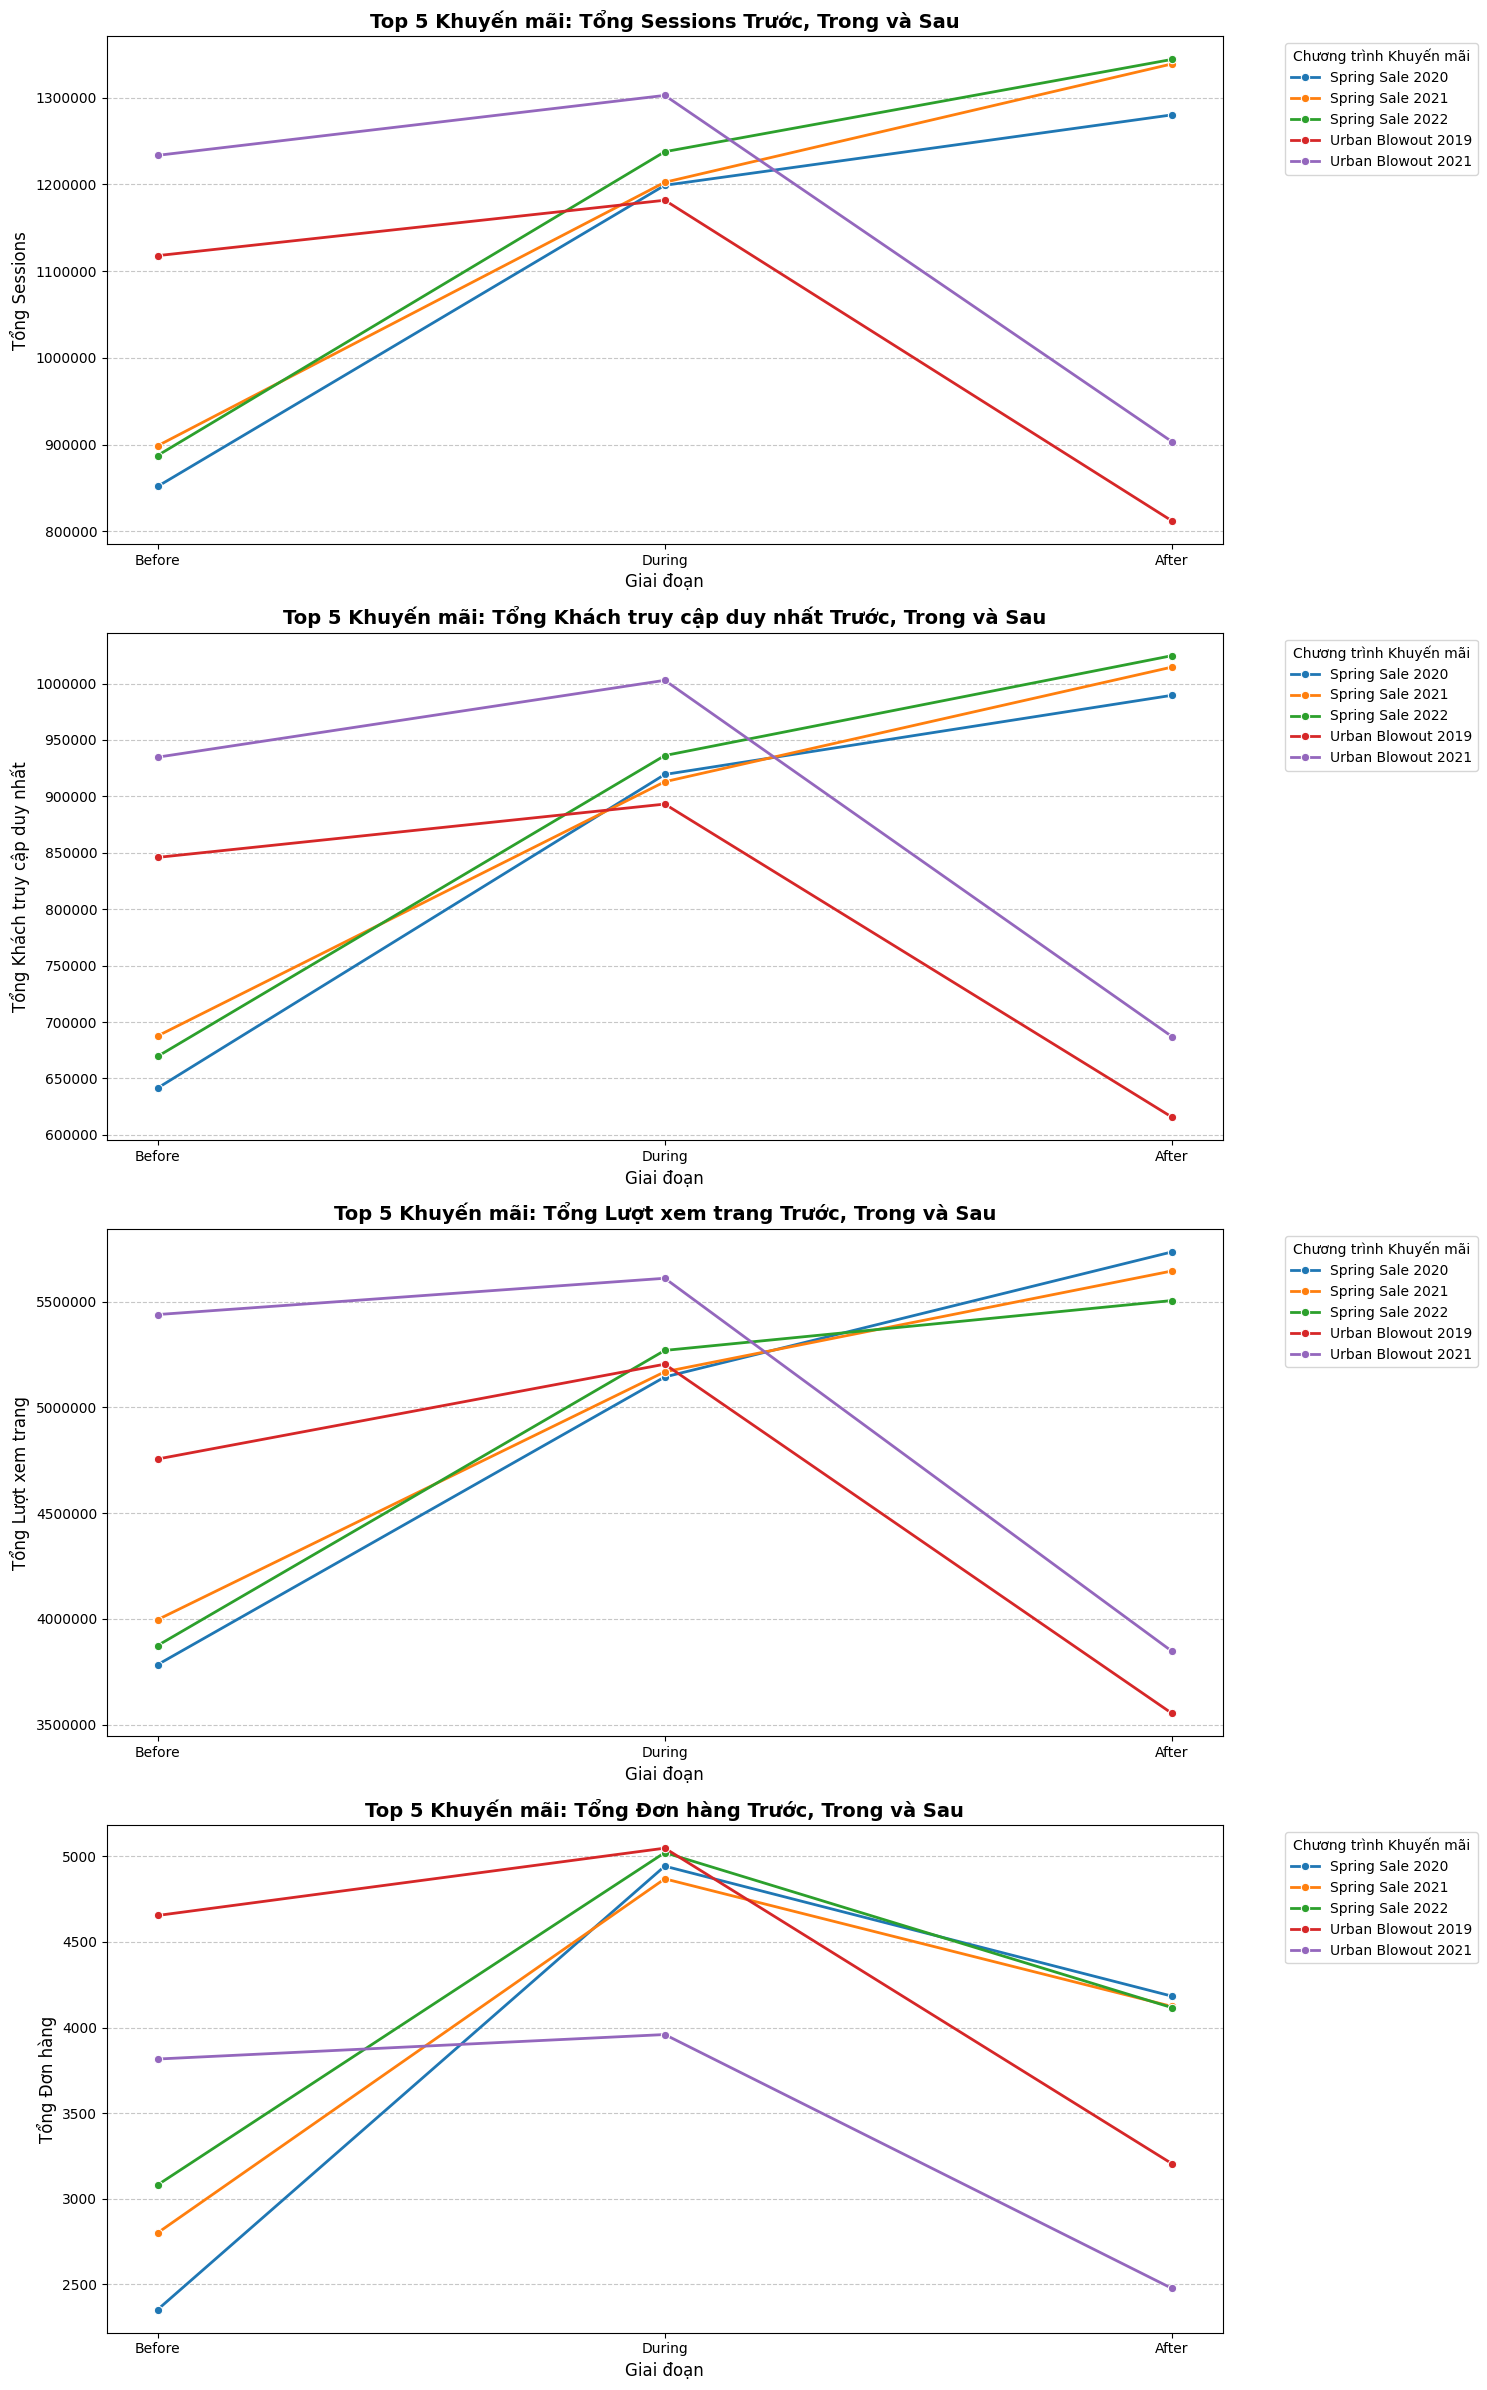

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_web_traffic dates are datetime objects
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])

# Ensure df_promotions dates are datetime objects
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

# Ensure fact_sales order_date is datetime object for filtering
fact_sales['order_date'] = pd.to_datetime(fact_sales['order_date'])


comparison_traffic_data = []

for index, promo_row in df_promotions.iterrows():
    promo_id = promo_row['promo_id']
    promo_name = promo_row['promo_name']
    start_date = promo_row['start_date']
    end_date = promo_row['end_date']

    # Calculate duration of the promotion
    duration = (end_date - start_date).days + 1

    # Define 'Before' period
    before_end_date = start_date - pd.Timedelta(days=1)
    before_start_date = before_end_date - pd.Timedelta(days=duration - 1)

    # Define 'After' period
    after_start_date = end_date + pd.Timedelta(days=1)
    after_end_date = after_start_date + pd.Timedelta(days=duration - 1)

    periods = [
        ('Before', before_start_date, before_end_date),
        ('During', start_date, end_date),
        ('After', after_start_date, after_end_date)
    ]

    for period_name, p_start_date, p_end_date in periods:
        # Extract web traffic for the period
        traffic_for_period = df_web_traffic[
            (df_web_traffic['date'] >= p_start_date) &
            (df_web_traffic['date'] <= p_end_date)
        ]

        # Extract sales data for the period
        sales_for_period = fact_sales[
            (fact_sales['order_date'] >= p_start_date) &
            (fact_sales['order_date'] <= p_end_date)
        ]

        total_sessions = traffic_for_period['sessions'].sum() if not traffic_for_period.empty else 0
        total_unique_visitors = traffic_for_period['unique_visitors'].sum() if not traffic_for_period.empty else 0
        total_page_views = traffic_for_period['page_views'].sum() if not traffic_for_period.empty else 0
        total_orders = sales_for_period['order_id'].nunique() if not sales_for_period.empty else 0 # Count unique order_ids

        comparison_traffic_data.append({
            'promo_id': promo_id,
            'promo_name': promo_name,
            'period': period_name,
            'total_sessions': total_sessions,
            'total_unique_visitors': total_unique_visitors,
            'total_page_views': total_page_views,
            'total_orders': total_orders # Add total orders
        })

promo_traffic_comparison_df = pd.DataFrame(comparison_traffic_data)

print("--- So sánh Web Traffic và Doanh số Trước, Trong và Sau Khuyến mãi (Top 15 hàng đầu) ---")
print(promo_traffic_comparison_df.head(15))
print("-" * 80)

# Visualization: Line plots for top N promotions
# Let's focus on top 5 promotions by 'during' sessions for clearer visualization
top_n = 5
top_promos_by_sessions_during = promo_traffic_comparison_df[
    promo_traffic_comparison_df['period'] == 'During'
].nlargest(top_n, 'total_sessions')['promo_name'].tolist()

plot_df = promo_traffic_comparison_df[
    promo_traffic_comparison_df['promo_name'].isin(top_promos_by_sessions_during)
].copy()

# Ensure consistent order for periods in plotting
plot_df['period'] = pd.Categorical(plot_df['period'], categories=['Before', 'During', 'After'], ordered=True)
plot_df = plot_df.sort_values(by=['promo_name', 'period'])

metrics = ['total_sessions', 'total_unique_visitors', 'total_page_views', 'total_orders'] # Add total_orders to metrics
titles = ['Tổng Sessions', 'Tổng Khách truy cập duy nhất', 'Tổng Lượt xem trang', 'Tổng Đơn hàng'] # Add title for total_orders

fig, axes = plt.subplots(len(metrics), 1, figsize=(15, 6 * len(metrics)))

for i, metric in enumerate(metrics):
    sns.lineplot(
        x='period',
        y=metric,
        hue='promo_name',
        data=plot_df,
        marker='o',
        ax=axes[i],
        linewidth=2
    )
    axes[i].set_title(f'Top {top_n} Khuyến mãi: {titles[i]} Trước, Trong và Sau', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Giai đoạn', fontsize=12)
    axes[i].set_ylabel(titles[i], fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='y')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend(title='Chương trình Khuyến mãi', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()